<h1 style="color:orange;">Exploración Inicial del Dataset 04 N-CMAPSS</h1>
<p> Valentina Arce España <p>
<p> Febrero 10, 2026 <p>
<p> Este set se enfoca en fallas de eficiencia y flujo del ventilador.<p>

In [5]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ruta al archivo (asegúrate de que el nombre sea el correcto para el DS04)
file_path = 'N-CMAPSS_DS04.h5'

# 1. Abrir el archivo en modo lectura ('r')
with h5py.File(file_path, 'r') as hdf:
    # Listar todas las llaves principales para ver qué hay dentro
    print("Llaves principales en el archivo HDF5:")
    print(list(hdf.keys()))

Llaves principales en el archivo HDF5:
['A_dev', 'A_test', 'A_var', 'T_dev', 'T_test', 'T_var', 'W_dev', 'W_test', 'W_var', 'X_s_dev', 'X_s_test', 'X_s_var', 'X_v_dev', 'X_v_test', 'X_v_var', 'Y_dev', 'Y_test']


In [6]:
with h5py.File(file_path, 'r') as hdf:
    # Cargar nombres de variables (decodificamos de bytes a strings para leerlos bien)
    w_cols = np.array(hdf.get('W_var')).astype(str)   # Condiciones Operativas
    x_s_cols = np.array(hdf.get('X_s_var')).astype(str) # Sensores Físicos
    x_v_cols = np.array(hdf.get('X_v_var')).astype(str) # Sensores Virtuales
    t_cols = np.array(hdf.get('T_var')).astype(str)   # Theta (Salud del motor)
    a_cols = np.array(hdf.get('A_var')).astype(str)   # Información Auxiliar

    print("Columnas W (Operativas):", w_cols)
    print("Columnas X_s (Sensores):", x_s_cols)
    print("Columnas T (Theta/Salud):", t_cols)
    print("Columnas A (Auxiliares):", a_cols)

Columnas W (Operativas): ['alt' 'Mach' 'TRA' 'T2']
Columnas X_s (Sensores): ['T24' 'T30' 'T48' 'T50' 'P15' 'P2' 'P21' 'P24' 'Ps30' 'P40' 'P50' 'Nf'
 'Nc' 'Wf']
Columnas T (Theta/Salud): ['fan_eff_mod' 'fan_flow_mod' 'LPC_eff_mod' 'LPC_flow_mod' 'HPC_eff_mod'
 'HPC_flow_mod' 'HPT_eff_mod' 'HPT_flow_mod' 'LPT_eff_mod' 'LPT_flow_mod']
Columnas A (Auxiliares): ['unit' 'cycle' 'Fc' 'hs']


In [7]:
with h5py.File(file_path, 'r') as hdf:
    # Cargamos A_dev (Auxiliary data del set de desarrollo)
    A_dev = np.array(hdf.get('A_dev'))

# Crear DataFrame de Pandas para verlo bonito
df_A = pd.DataFrame(A_dev, columns=a_cols)

print("Primeras 5 filas de Información Auxiliar:")
print(df_A.head())

print("\nEstadísticas (mira los IDs de unidad y ciclos):")
print(df_A.describe())

Primeras 5 filas de Información Auxiliar:
   unit  cycle   Fc   hs
0   1.0    1.0  2.0  1.0
1   1.0    1.0  2.0  1.0
2   1.0    1.0  2.0  1.0
3   1.0    1.0  2.0  1.0
4   1.0    1.0  2.0  1.0

Estadísticas (mira los IDs de unidad y ciclos):
               unit         cycle            Fc            hs
count  6.377452e+06  6.377452e+06  6.377452e+06  6.377452e+06
mean   3.751294e+00  4.355893e+01  2.733713e+00  2.020726e-01
std    1.679448e+00  2.591157e+01  4.420163e-01  4.015461e-01
min    1.000000e+00  1.000000e+00  2.000000e+00  0.000000e+00
25%    2.000000e+00  2.200000e+01  2.000000e+00  0.000000e+00
50%    4.000000e+00  4.300000e+01  3.000000e+00  0.000000e+00
75%    5.000000e+00  6.400000e+01  3.000000e+00  0.000000e+00
max    6.000000e+00  1.000000e+02  3.000000e+00  1.000000e+00


In [8]:
# Agrupar por 'unit' y contar el máximo de 'cycle'
vida_util = df_A.groupby('unit')['cycle'].max()

print("Vida útil (ciclos totales) por cada motor en el set de desarrollo:")
print(vida_util)

# Ver qué unidades tenemos disponibles
print("\nIDs de las Unidades disponibles:", df_A['unit'].unique())

Vida útil (ciclos totales) por cada motor en el set de desarrollo:
unit
1.0     87.0
2.0     73.0
3.0    100.0
4.0     69.0
5.0    100.0
6.0     83.0
Name: cycle, dtype: float64

IDs de las Unidades disponibles: [1. 2. 3. 4. 5. 6.]


In [9]:
with h5py.File(file_path, 'r') as hdf:
    # Cargar datos numéricos
    W_dev = np.array(hdf.get('W_dev'))
    X_s_dev = np.array(hdf.get('X_s_dev'))

# Crear DataFrames
df_W = pd.DataFrame(W_dev, columns=w_cols)
df_X_s = pd.DataFrame(X_s_dev, columns=x_s_cols)

# Añadir la columna de unidad para saber a quién pertenece cada fila
df_W['unit'] = df_A['unit']
df_X_s['unit'] = df_A['unit']

print("Condiciones Operativas (W) - Ejemplo:")
print(df_W.head())

print("\nLecturas de Sensores (X_s) - Ejemplo:")
print(df_X_s.head())

Condiciones Operativas (W) - Ejemplo:
      alt      Mach        TRA          T2  unit
0  3003.0  0.261135  81.386139  514.889127   1.0
1  3014.0  0.260820  81.386139  514.832078   1.0
2  3023.0  0.262521  81.386139  514.889656   1.0
3  3032.0  0.262836  81.386139  514.874556   1.0
4  3042.0  0.262332  81.386139  514.811204   1.0

Lecturas de Sensores (X_s) - Ejemplo:
          T24          T30          T48          T50        P15         P2  \
0  620.536686  1500.497778  1918.887446  1305.895297  19.186726  13.769427   
1  620.212233  1501.026264  1918.174792  1306.704845  19.168470  13.765780   
2  620.691023  1501.435624  1917.553771  1305.988738  19.161991  13.768780   
3  620.355416  1500.911321  1917.426968  1305.531529  19.171850  13.754179   
4  620.591359  1501.437449  1918.752200  1305.696191  19.161257  13.744312   

         P21        P24        Ps30         P40        P50           Nf  \
0  19.462331  24.474988  420.022739  426.578936  16.312785  2229.036206   
1  19.4725

In [11]:
with h5py.File(file_path, 'r') as hdf:
    # 1. Extraemos los nombres de las columnas (vienen como bytes)
    sensor_names = np.array(hdf.get('X_s_var')).astype(str) 
    
    # 2. Extraemos los datos crudos
    raw_sensors = np.array(hdf.get('X_s_dev'))

# 3. Al crear el DataFrame de Pandas, le pasamos los nombres que extrajimos
df_sensors = pd.DataFrame(data=raw_sensors, columns=sensor_names)

print("Orden oficial de los sensores en DS01:")
print(sensor_names)

Orden oficial de los sensores en DS01:
['T24' 'T30' 'T48' 'T50' 'P15' 'P2' 'P21' 'P24' 'Ps30' 'P40' 'P50' 'Nf'
 'Nc' 'Wf']


In [13]:
with h5py.File(file_path, 'r') as hdf:
    T_dev = np.array(hdf.get('T_dev'))

df_T = pd.DataFrame(T_dev, columns=t_cols)
df_T['unit'] = df_A['unit']

print("Parámetros de Salud (Theta) - Ejemplo:")
print(df_T.head())

Parámetros de Salud (Theta) - Ejemplo:
   fan_eff_mod  fan_flow_mod  LPC_eff_mod  LPC_flow_mod  HPC_eff_mod  \
0    -0.000185     -0.000445          0.0           0.0          0.0   
1    -0.000185     -0.000445          0.0           0.0          0.0   
2    -0.000185     -0.000445          0.0           0.0          0.0   
3    -0.000185     -0.000445          0.0           0.0          0.0   
4    -0.000185     -0.000445          0.0           0.0          0.0   

   HPC_flow_mod  HPT_eff_mod  HPT_flow_mod  LPT_eff_mod  LPT_flow_mod  unit  
0           0.0          0.0           0.0          0.0           0.0   1.0  
1           0.0          0.0           0.0          0.0           0.0   1.0  
2           0.0          0.0           0.0          0.0           0.0   1.0  
3           0.0          0.0           0.0          0.0           0.0   1.0  
4           0.0          0.0           0.0          0.0           0.0   1.0  


<h2 style="color:orange;">Visualizaciones Iniciales: Motor 1 - Flight Class 2</h2>

El sensor T50 está en el índice: 3


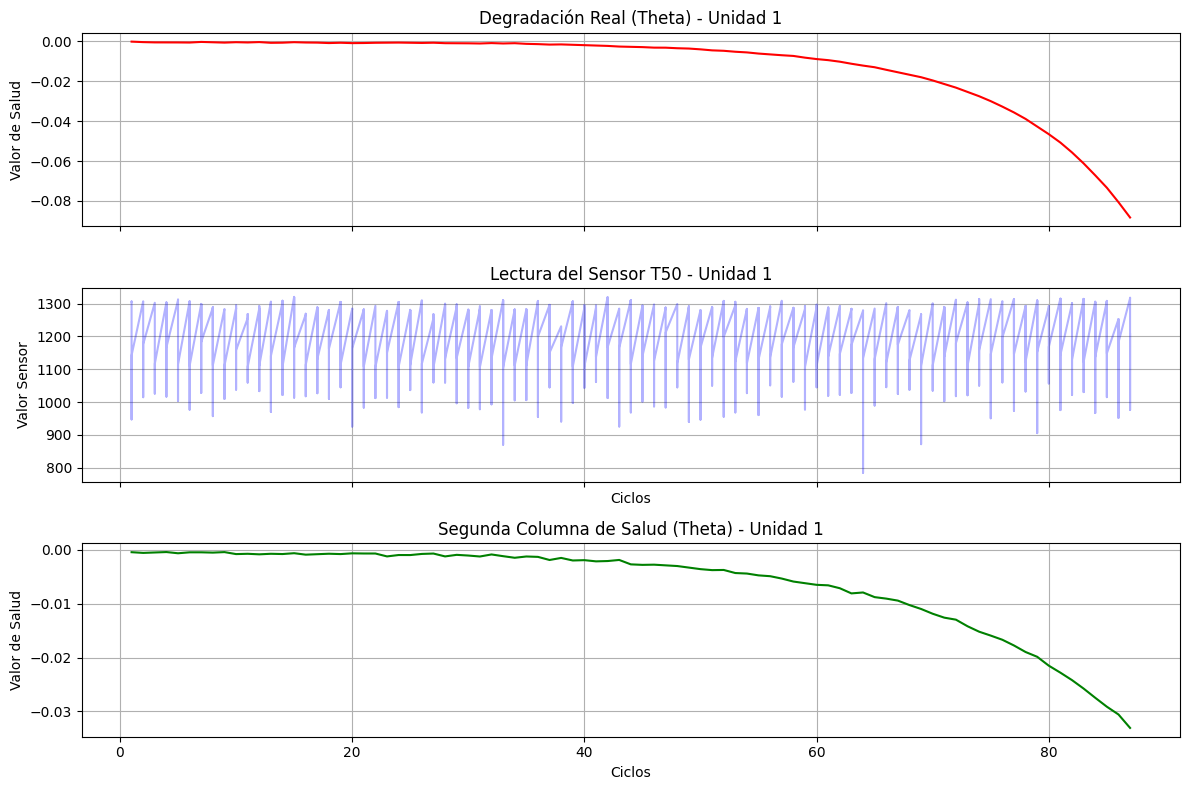

In [19]:
import matplotlib.pyplot as plt
unit_id = 1

with h5py.File(file_path, 'r') as hdf:
    # 1. Primero, leemos los nombres de los sensores para encontrar el índice correcto
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Buscamos en qué posición está 'T50'
    # Esto evita el IndexError porque busca dinámicamente
    try:
        t50_index = np.where(sensor_names == 'T50')[0][0]
        print(f"El sensor T50 está en el índice: {t50_index}")
    except IndexError:
        print("El sensor T50 no se encontró. Los sensores disponibles son:", sensor_names)
        # Si no está T50, podrías elegir otro como 'T24' o el último disponible
        t50_index = 0 

    # 2. Extraer datos de la Unidad 1 con la máscara
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    
    cycles = A_dev[mask, 1]
    
    # Extraer Theta (Salud) - En DS01 suele haber solo 2 (HPT y LPT) o incluso 1
    # Vamos a extraer la primera columna de salud disponible
    theta_data = hdf.get('T_dev')[mask, 0]
    theta_data_2 = hdf.get('T_dev')[mask, 1] 

    # Extraer el sensor usando el índice que encontramos arriba
    sensor_data = hdf.get('X_s_dev')[mask, t50_index]

# 3. Graficar
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

ax1.plot(cycles, theta_data, color='red')
ax1.set_title(f'Degradación Real (Theta) - Unidad {unit_id}')
ax1.set_ylabel('Valor de Salud')
ax1.grid(True)

ax2.plot(cycles, sensor_data, color='blue', alpha=0.3) # Alpha para ver mejor la densidad
ax2.set_title(f'Lectura del Sensor {sensor_names[t50_index]} - Unidad {unit_id}')
ax2.set_ylabel('Valor Sensor')
ax2.set_xlabel('Ciclos')
ax2.grid(True)

ax3.plot(cycles, theta_data_2, color='green')
ax3.set_title(f'Segunda Columna de Salud (Theta) - Unidad {unit_id}')
ax3.set_ylabel('Valor de Salud')
ax3.set_xlabel('Ciclos')
ax3.grid(True)

plt.tight_layout()
plt.show()

Sensores a graficar: ['T24', 'T30', 'T50', 'Wf', 'Nf', 'Nc']


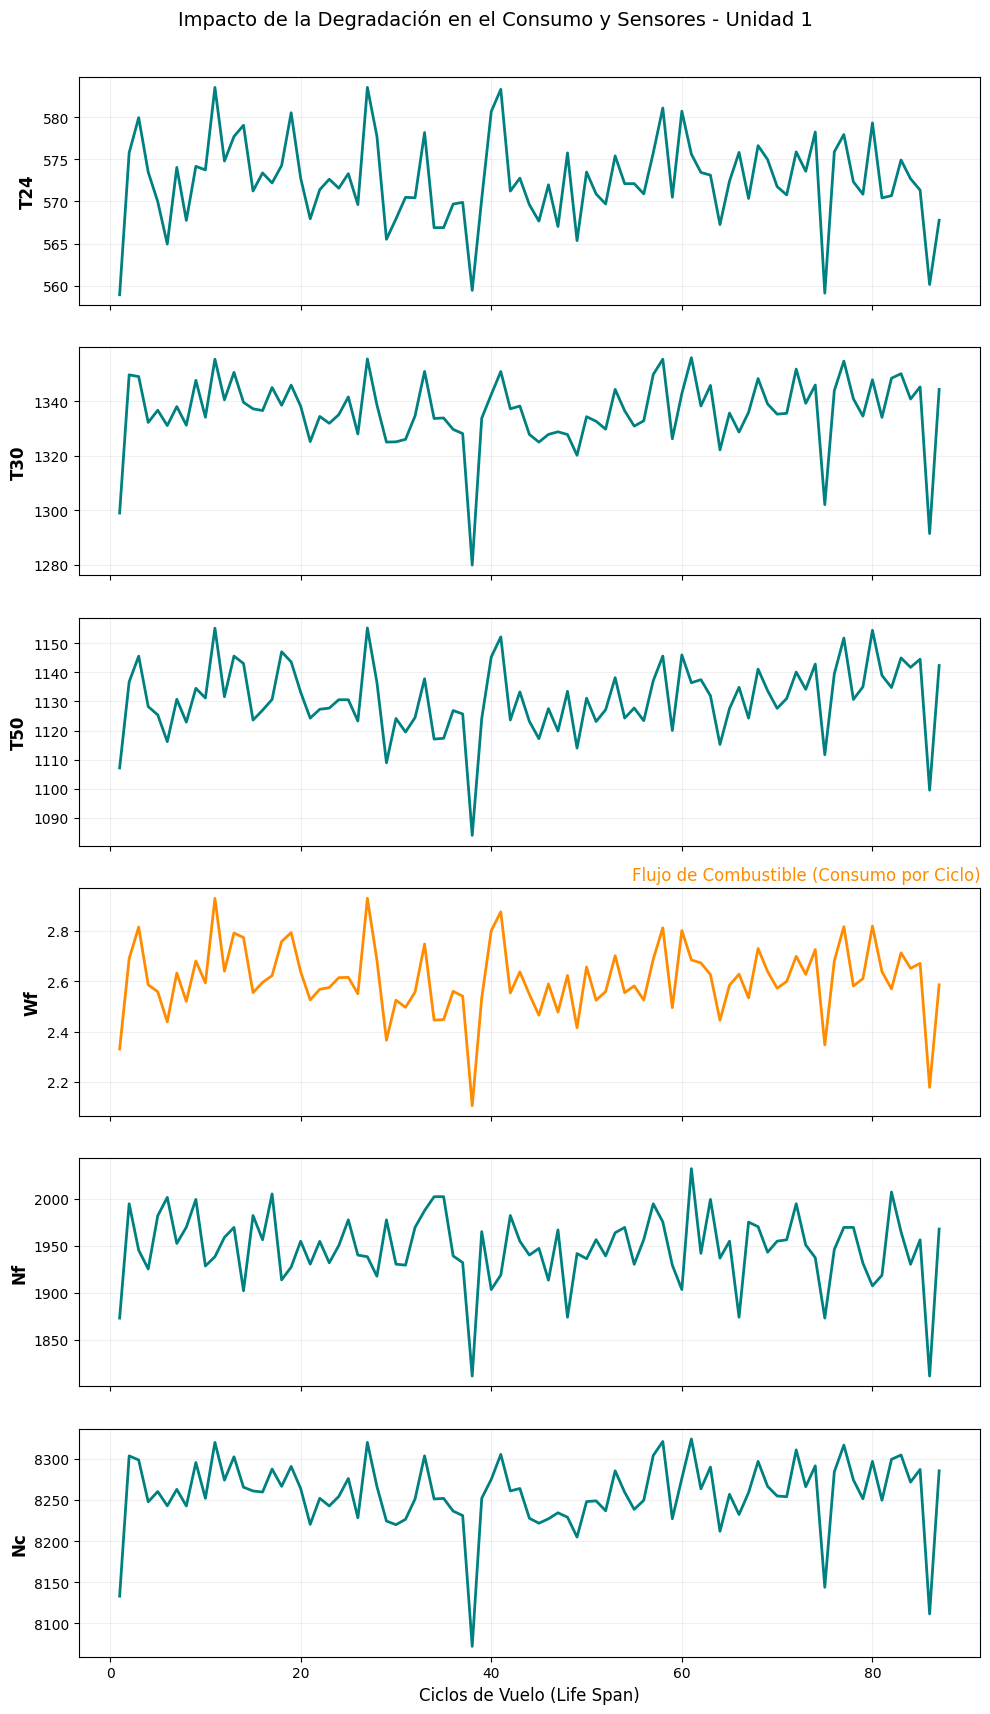

In [18]:
# Agregamos Wf a nuestra lista de deseos
sensores_interesantes = ['T24', 'T30', 'T50', 'P30', 'Wf', 'Nf', 'Nc']

with h5py.File(file_path, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Verificamos cuáles existen (Wf suele estar en la posición 10-12 aprox)
    sensores_validos = [s for s in sensores_interesantes if s in sensor_names]
    print(f"Sensores a graficar: {sensores_validos}")

    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]
    
    fig, axes = plt.subplots(len(sensores_validos), 1, figsize=(10, 3 * len(sensores_validos)), sharex=True)
    
    if len(sensores_validos) == 1: axes = [axes]

    for i, s_name in enumerate(sensores_validos):
        idx = np.where(sensor_names == s_name)[0][0]
        data_sensor = hdf.get('X_s_dev')[mask, idx]
        
        # Promediado por ciclo
        df_s = pd.DataFrame({'cycle': cycles, 'val': data_sensor})
        df_s_avg = df_s.groupby('cycle').mean()
        
        # Usamos un color naranja para Wf para destacarlo
        color = 'darkorange' if s_name == 'Wf' else 'teal'
        
        axes[i].plot(df_s_avg.index, df_s_avg['val'], color=color, linewidth=2)
        axes[i].set_ylabel(f"{s_name}", fontsize=12, fontweight='bold')
        axes[i].grid(True, alpha=0.2)
        
        if s_name == 'Wf':
            axes[i].set_title("Flujo de Combustible (Consumo por Ciclo)", loc='right', color='darkorange')

axes[-1].set_xlabel('Ciclos de Vuelo (Life Span)', fontsize=12)
plt.suptitle(f'Impacto de la Degradación en el Consumo y Sensores - Unidad {unit_id}', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

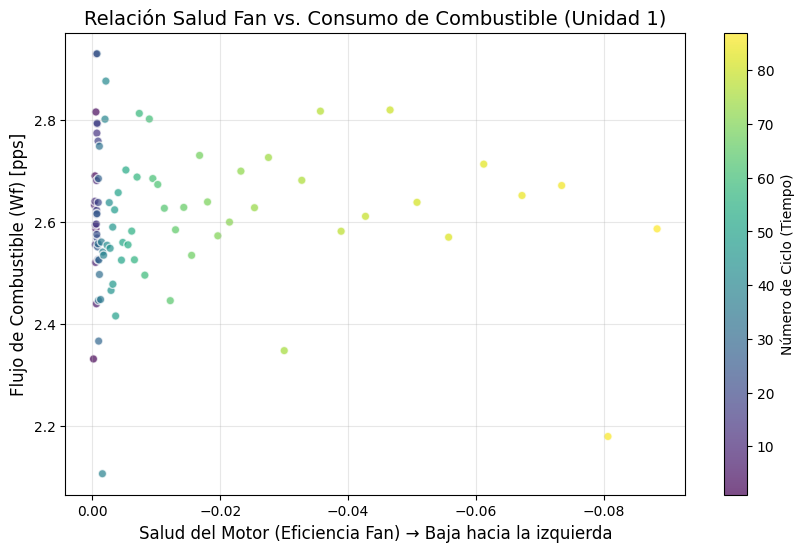

In [21]:
with h5py.File(file_path, 'r') as hdf:
    # 1. Obtener nombres y localizar índices
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    
    # 2. Extraer datos
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]
    
    theta_hpt = hdf.get('T_dev')[mask, 0]  # Usamos la columna 0 para Fan
    wf_data = hdf.get('X_s_dev')[mask, wf_idx]

    # 3. Consolidar promedios por ciclo para evitar el ruido de cada segundo
    df_corr = pd.DataFrame({
        'cycle': cycles,
        'salud_hpt': theta_hpt,
        'combustible': wf_data
    })
    df_avg = df_corr.groupby('cycle').mean()

# 4. Graficar la Correlación
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_avg['salud_hpt'], df_avg['combustible'], 
                      c=df_avg.index, cmap='viridis', alpha=0.7, edgecolors='w')

# Añadir barra de color para ver el paso del tiempo (ciclos)
cbar = plt.colorbar(scatter)
cbar.set_label('Número de Ciclo (Tiempo)')

plt.title(f'Relación Salud Fan vs. Consumo de Combustible (Unidad {unit_id})', fontsize=14)
plt.xlabel('Salud del Motor (Eficiencia Fan) → Baja hacia la izquierda', fontsize=12)
plt.ylabel('Flujo de Combustible (Wf) [pps]', fontsize=12)
plt.grid(True, alpha=0.3)

# Invertir el eje X puede ayudar a visualizar el "avance" de la falla
plt.gca().invert_xaxis() 

plt.show()

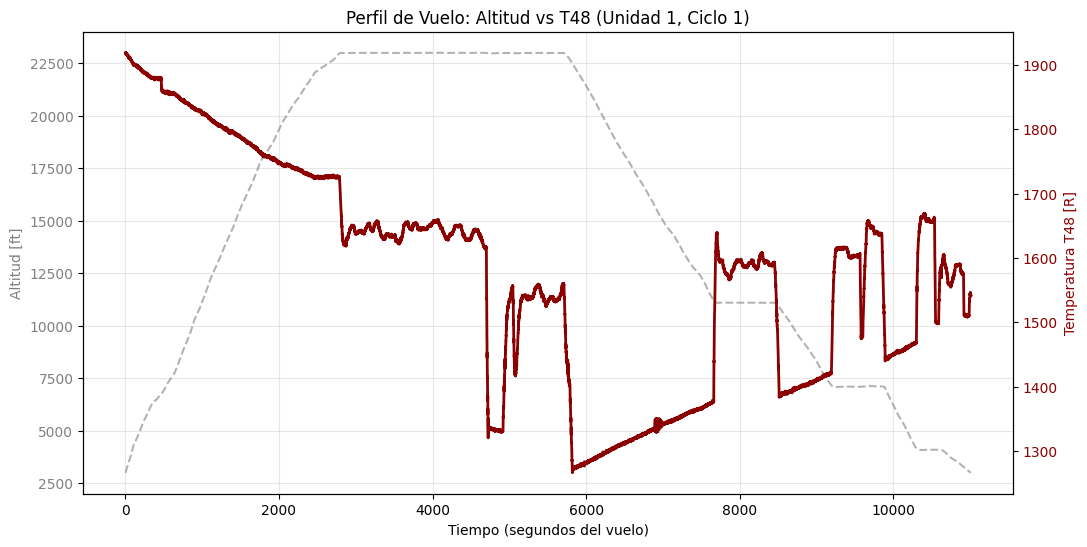

In [ ]:
vuelo_id = 1 # Vamos a ver solo el primer vuelo

with h5py.File(file_path, 'r') as hdf:
    # 1. Localizar índices de Altitud (en W) y T48 (en X_s)
    w_names = np.array(hdf.get('W_var')).astype(str)
    s_names = np.array(hdf.get('X_s_var')).astype(str)
    
    alt_idx = np.where(w_names == 'alt')[0][0]
    t48_idx = np.where(s_names == 'T48')[0][0]
    
    # 2. Extraer datos de la Unidad 1
    A_dev = hdf.get('A_dev')[:]
    # Máscara doble: Unidad 1 Y Ciclo 1
    mask_vuelo = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == vuelo_id)
    
    alt_data = hdf.get('W_dev')[mask_vuelo, alt_idx]
    t48_data = hdf.get('X_s_dev')[mask_vuelo, t48_idx]
    
    # Creamos un eje de tiempo (puntos de datos)
    time_steps = np.arange(len(alt_data))

# 3. Graficar
fig, ax1 = plt.subplots(figsize=(12, 6))

# Altitud (Eje Izquierdo)
ax1.plot(time_steps, alt_data, color='gray', linestyle='--', alpha=0.6, label='Altitud')
ax1.set_xlabel('Tiempo (segundos del vuelo)')
ax1.set_ylabel('Altitud [ft]', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# T48 (Eje Derecho)
ax2 = ax1.twinx()
ax2.plot(time_steps, t48_data, color='darkred', linewidth=2, label='Temperatura T48')
ax2.set_ylabel('Temperatura T48 [R]', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title(f'Perfil de Vuelo: Altitud vs T48 (Unidad {unit_id}, Ciclo {vuelo_id})')
ax1.grid(True, alpha=0.3)
plt.show()

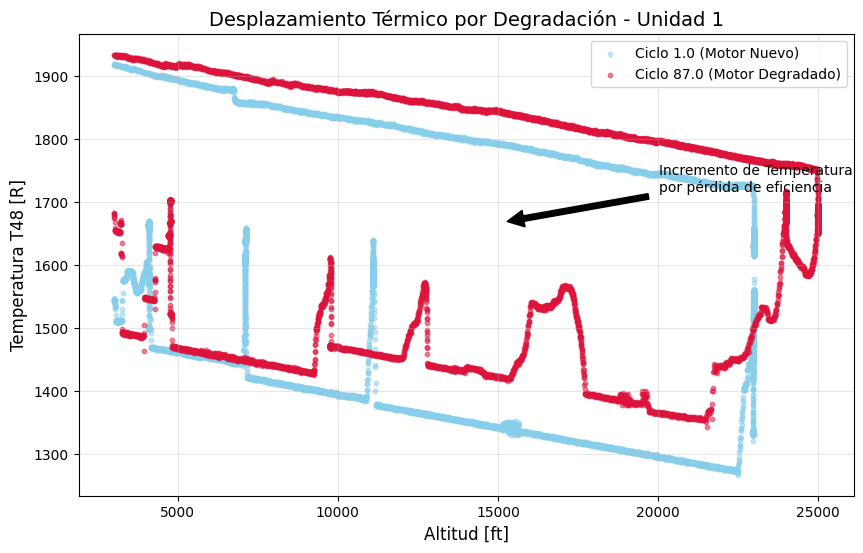

In [ ]:
with h5py.File(file_path, 'r') as hdf:
    # 1. Localizar índices
    w_names = np.array(hdf.get('W_var')).astype(str)
    s_names = np.array(hdf.get('X_s_var')).astype(str)
    alt_idx = np.where(w_names == 'alt')[0][0]
    t48_idx = np.where(s_names == 'T48')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    u_mask = A_dev[:, 0] == unit_id
    vuelos_disponibles = np.unique(A_dev[u_mask, 1])
    
    ciclo_joven = vuelos_disponibles[0]  # Ciclo 1
    ciclo_viejo = vuelos_disponibles[-1] # Último ciclo antes de falla
    
    # 2. Extraer datos para ambos ciclos
    def get_vuelo_data(c_id):
        mask = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == c_id)
        return hdf.get('W_dev')[mask, alt_idx], hdf.get('X_s_dev')[mask, t48_idx]

    alt_joven, t48_joven = get_vuelo_data(ciclo_joven)
    alt_viejo, t48_viejo = get_vuelo_data(ciclo_viejo)

# 3. Graficar
plt.figure(figsize=(10, 6))

# Usamos scatter porque los puntos no están necesariamente en orden de altitud
plt.scatter(alt_joven, t48_joven, color='skyblue', alpha=0.5, s=10, label=f'Ciclo {ciclo_joven} (Motor Nuevo)')
plt.scatter(alt_viejo, t48_viejo, color='crimson', alpha=0.5, s=10, label=f'Ciclo {ciclo_viejo} (Motor Degradado)')

plt.title(f'Desplazamiento Térmico por Degradación - Unidad {unit_id}', fontsize=14)
plt.xlabel('Altitud [ft]', fontsize=12)
plt.ylabel('Temperatura T48 [R]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Añadir una flecha que indique el desplazamiento
plt.annotate('Incremento de Temperatura\npor pérdida de eficiencia', 
             xy=(alt_joven.mean(), t48_viejo.mean()), 
             xytext=(alt_joven.mean() + 5000, t48_viejo.mean() + 50),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

plt.show()

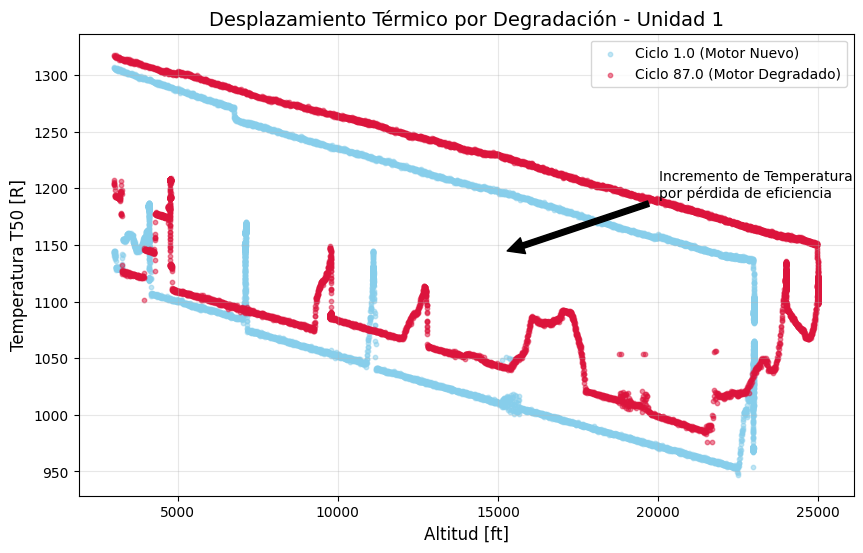

In [27]:
with h5py.File(file_path, 'r') as hdf:
    # 1. Localizar índices
    w_names = np.array(hdf.get('W_var')).astype(str)
    s_names = np.array(hdf.get('X_s_var')).astype(str)
    alt_idx = np.where(w_names == 'alt')[0][0]
    t48_idx = np.where(s_names == 'T50')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    u_mask = A_dev[:, 0] == unit_id
    vuelos_disponibles = np.unique(A_dev[u_mask, 1])
    
    ciclo_joven = vuelos_disponibles[0]  # Ciclo 1
    ciclo_viejo = vuelos_disponibles[-1] # Último ciclo antes de falla
    
    # 2. Extraer datos para ambos ciclos
    def get_vuelo_data(c_id):
        mask = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == c_id)
        return hdf.get('W_dev')[mask, alt_idx], hdf.get('X_s_dev')[mask, t48_idx]

    alt_joven, t48_joven = get_vuelo_data(ciclo_joven)
    alt_viejo, t48_viejo = get_vuelo_data(ciclo_viejo)

# 3. Graficar
plt.figure(figsize=(10, 6))

# Usamos scatter porque los puntos no están necesariamente en orden de altitud
plt.scatter(alt_joven, t48_joven, color='skyblue', alpha=0.5, s=10, label=f'Ciclo {ciclo_joven} (Motor Nuevo)')
plt.scatter(alt_viejo, t48_viejo, color='crimson', alpha=0.5, s=10, label=f'Ciclo {ciclo_viejo} (Motor Degradado)')

plt.title(f'Desplazamiento Térmico por Degradación - Unidad {unit_id}', fontsize=14)
plt.xlabel('Altitud [ft]', fontsize=12)
plt.ylabel('Temperatura T50 [R]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Añadir una flecha que indique el desplazamiento
plt.annotate('Incremento de Temperatura\npor pérdida de eficiencia', 
             xy=(alt_joven.mean(), t48_viejo.mean()), 
             xytext=(alt_joven.mean() + 5000, t48_viejo.mean() + 50),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

plt.show()

Presiones encontradas: [np.str_('P15'), np.str_('P2'), np.str_('P21'), np.str_('P24'), np.str_('Ps30'), np.str_('P40'), np.str_('P50')]


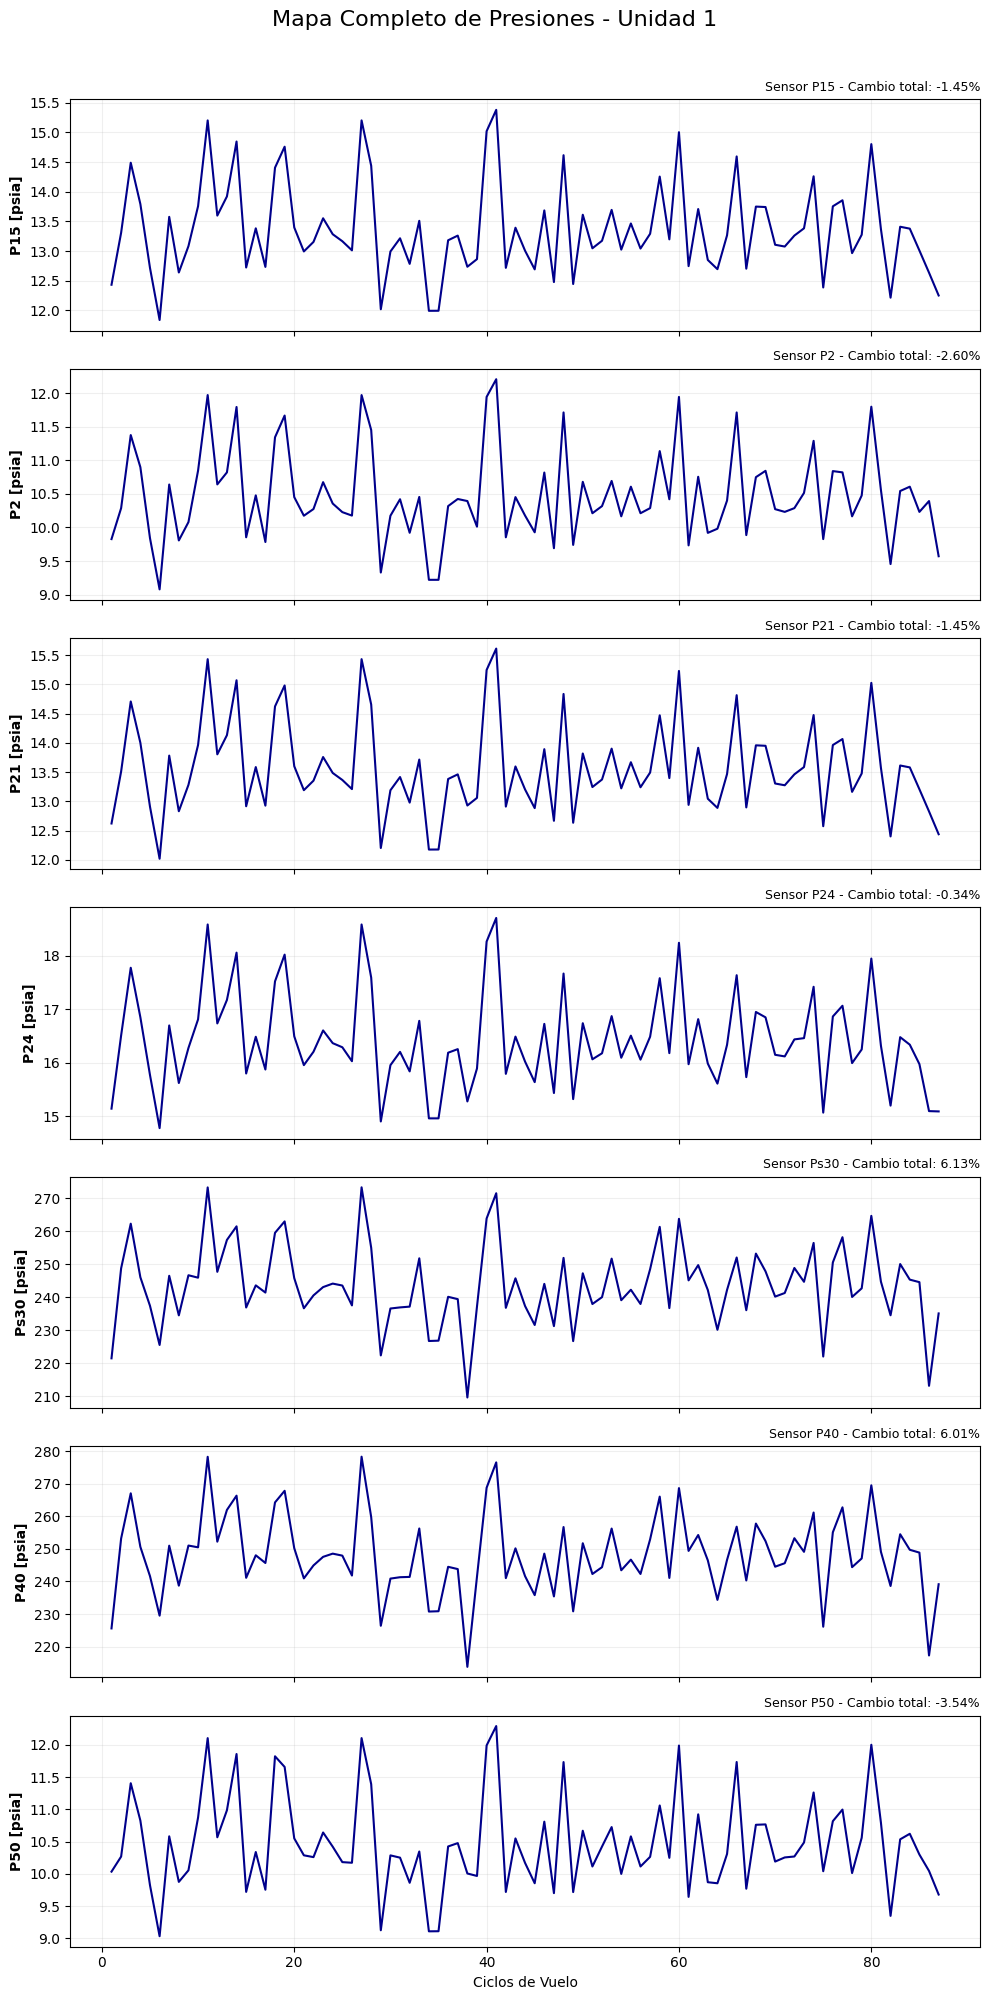

In [29]:
with h5py.File(file_path, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Identificamos todos los sensores que empiezan con 'P'
    presiones_disponibles = [s for s in sensor_names if s.startswith('P')]
    print(f"Presiones encontradas: {presiones_disponibles}")
    
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]

    # Configuramos una cuadrícula de subplots
    n_p = len(presiones_disponibles)
    fig, axes = plt.subplots(n_p, 1, figsize=(10, 3 * n_p), sharex=True)
    
    # Aseguramos que axes sea una lista si solo hay una presión
    if n_p == 1: axes = [axes]

    for i, p_name in enumerate(presiones_disponibles):
        idx = np.where(sensor_names == p_name)[0][0]
        data_raw = hdf.get('X_s_dev')[mask, idx]
        
        # Promedio por ciclo para ver la tendencia limpia
        df_tmp = pd.DataFrame({'cycle': cycles, 'val': data_raw})
        df_avg = df_tmp.groupby('cycle').mean()
        
        axes[i].plot(df_avg.index, df_avg['val'], color='darkblue', linewidth=1.5)
        axes[i].set_ylabel(f"{p_name} [psia]", fontweight='bold')
        axes[i].grid(True, alpha=0.2)
        
        # Calcular el cambio porcentual total para ver qué tanto varió
        delta = ((df_avg['val'].iloc[-1] - df_avg['val'].iloc[0]) / df_avg['val'].iloc[0]) * 100
        axes[i].set_title(f"Sensor {p_name} - Cambio total: {delta:.2f}%", loc='right', fontsize=9)

axes[-1].set_xlabel('Ciclos de Vuelo')
plt.suptitle(f'Mapa Completo de Presiones - Unidad {unit_id}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

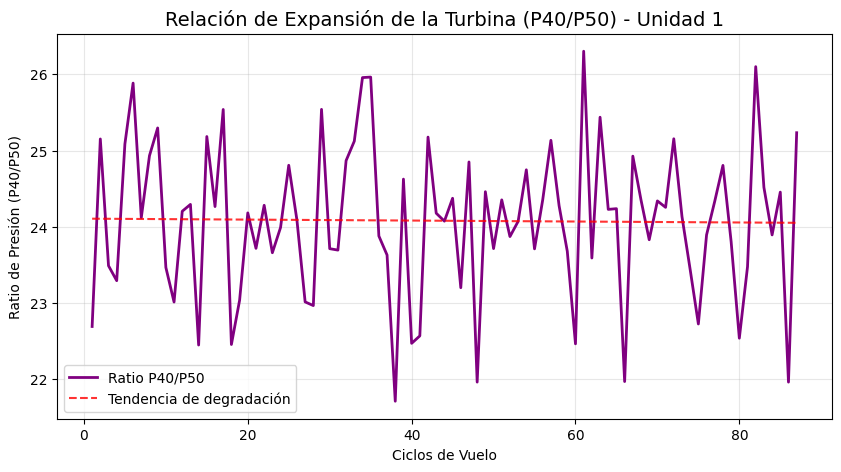

Ratio inicial: 22.6903
Ratio final: 25.2334


In [31]:
with h5py.File(file_path, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Verificamos si P40 y P50 existen en el dataset
    if 'P40' in sensor_names and 'P50' in sensor_names:
        idx_p40 = np.where(sensor_names == 'P40')[0][0]
        idx_p50 = np.where(sensor_names == 'P50')[0][0]
        
        A_dev = hdf.get('A_dev')[:]
        mask = A_dev[:, 0] == unit_id
        cycles = A_dev[mask, 1]
        
        # Extraemos datos
        p40_data = hdf.get('X_s_dev')[mask, idx_p40]
        p50_data = hdf.get('X_s_dev')[mask, idx_p50]
        
        # Creamos el DataFrame para promediar por ciclo
        df_ratio = pd.DataFrame({
            'cycle': cycles,
            'ratio': p40_data / p50_data
        })
        df_avg = df_ratio.groupby('cycle').mean()
        
        # Graficamos
        plt.figure(figsize=(10, 5))
        plt.plot(df_avg.index, df_avg['ratio'], color='purple', linewidth=2, label='Ratio P40/P50')
        
        # Añadir línea de tendencia
        z = np.polyfit(df_avg.index, df_avg['ratio'], 1)
        p = np.poly1d(z)
        plt.plot(df_avg.index, p(df_avg.index), "r--", alpha=0.8, label='Tendencia de degradación')
        
        plt.title(f'Relación de Expansión de la Turbina (P40/P50) - Unidad {unit_id}', fontsize=14)
        plt.xlabel('Ciclos de Vuelo')
        plt.ylabel('Ratio de Presión (P40/P50)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"Ratio inicial: {df_avg['ratio'].iloc[0]:.4f}")
        print(f"Ratio final: {df_avg['ratio'].iloc[-1]:.4f}")
    else:
        print("Lo siento, P40 o P50 no están disponibles en este dataset (DS01).")
        print(f"Sensores disponibles: {[s for s in sensor_names if s.startswith('P')]}")

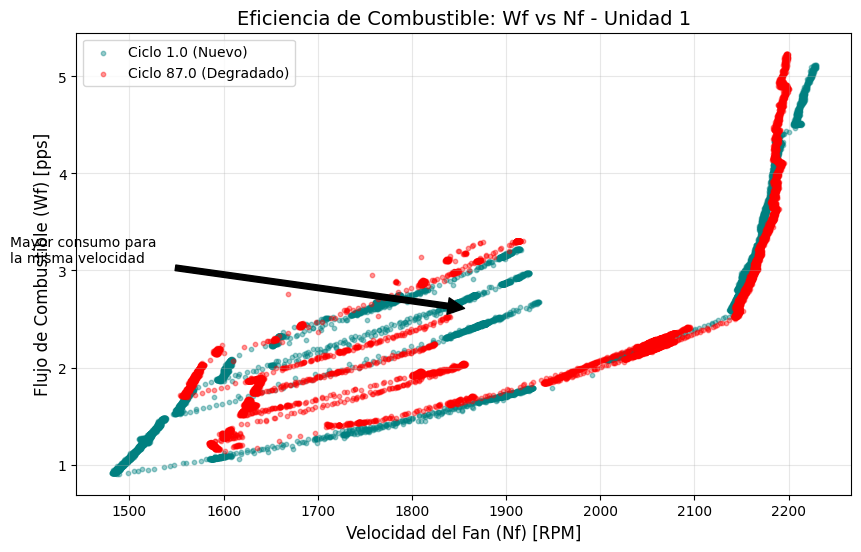

In [33]:
with h5py.File(file_path, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # 1. Localizar índices de Nf (Fan Speed) y Wf (Fuel Flow)
    nf_idx = np.where(sensor_names == 'Nf')[0][0]
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    u_mask = A_dev[:, 0] == unit_id
    vuelos = np.unique(A_dev[u_mask, 1])
    
    ciclo_ini = vuelos[0]
    ciclo_fin = vuelos[-1]
    
    # 2. Extraer datos (Unidad 1, Ciclos primero y último)
    mask_ini = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == ciclo_ini)
    mask_fin = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == ciclo_fin)
    
    nf_ini, wf_ini = hdf.get('X_s_dev')[mask_ini, nf_idx], hdf.get('X_s_dev')[mask_ini, wf_idx]
    nf_fin, wf_fin = hdf.get('X_s_dev')[mask_fin, nf_idx], hdf.get('X_s_dev')[mask_fin, wf_idx]

# 3. Graficar la relación
plt.figure(figsize=(10, 6))

plt.scatter(nf_ini, wf_ini, color='teal', alpha=0.4, s=10, label=f'Ciclo {ciclo_ini} (Nuevo)')
plt.scatter(nf_fin, wf_fin, color='red', alpha=0.4, s=10, label=f'Ciclo {ciclo_fin} (Degradado)')

plt.title(f'Eficiencia de Combustible: Wf vs Nf - Unidad {unit_id}', fontsize=14)
plt.xlabel('Velocidad del Fan (Nf) [RPM]', fontsize=12)
plt.ylabel('Flujo de Combustible (Wf) [pps]', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Dibujar una flecha para mostrar el "Fuel Penalty"
plt.annotate('Mayor consumo para\nla misma velocidad', 
             xy=(nf_ini.mean(), wf_fin.mean()), 
             xytext=(nf_ini.mean() - 500, wf_fin.mean() + 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

plt.show()

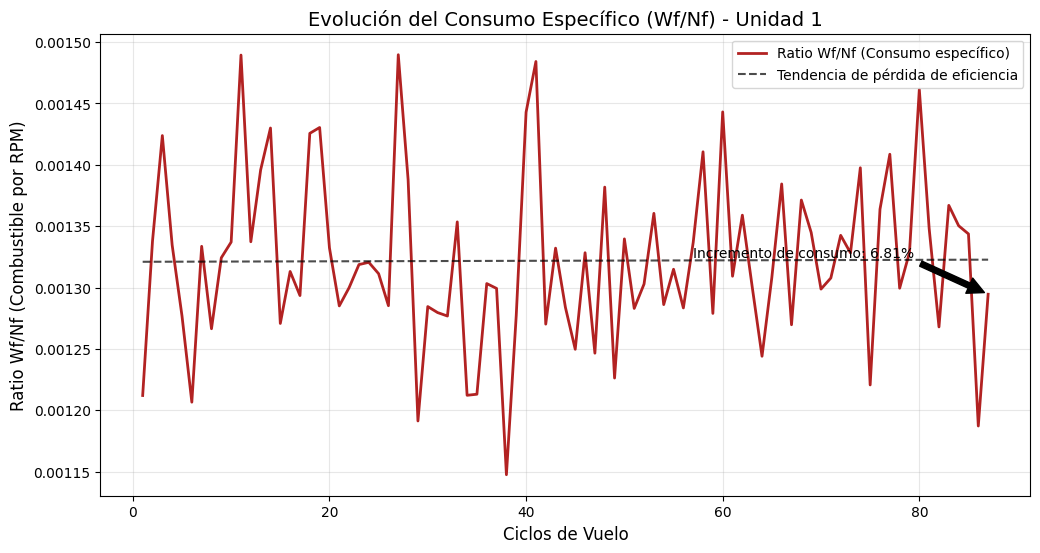

In [35]:
with h5py.File(file_path, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # 1. Localizar índices
    nf_idx = np.where(sensor_names == 'Nf')[0][0]
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]
    
    # 2. Extraer datos y calcular el ratio segundo a segundo
    nf_data = hdf.get('X_s_dev')[mask, nf_idx]
    wf_data = hdf.get('X_s_dev')[mask, wf_idx]
    
    # Creamos el ratio
    ratio_data = wf_data / nf_data
    
    # 3. Consolidar por ciclo para eliminar el ruido transitorio
    df_ratio = pd.DataFrame({'cycle': cycles, 'ratio': ratio_data})
    df_avg = df_ratio.groupby('cycle').mean()

# 4. Graficar la evolución
plt.figure(figsize=(12, 6))
plt.plot(df_avg.index, df_avg['ratio'], color='firebrick', linewidth=2, label='Ratio Wf/Nf (Consumo específico)')

# Añadir una línea de tendencia para ver la pendiente de degradación
z = np.polyfit(df_avg.index, df_avg['ratio'], 1)
p = np.poly1d(z)
plt.plot(df_avg.index, p(df_avg.index), "k--", alpha=0.7, label='Tendencia de pérdida de eficiencia')

plt.title(f'Evolución del Consumo Específico (Wf/Nf) - Unidad {unit_id}', fontsize=14)
plt.xlabel('Ciclos de Vuelo', fontsize=12)
plt.ylabel('Ratio Wf/Nf (Combustible por RPM)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Anotación del incremento porcentual
inc_perc = ((df_avg['ratio'].iloc[-1] - df_avg['ratio'].iloc[0]) / df_avg['ratio'].iloc[0]) * 100
plt.annotate(f'Incremento de consumo: {inc_perc:.2f}%', 
             xy=(df_avg.index[-1], df_avg['ratio'].iloc[-1]),
             xytext=(df_avg.index[-1]-30, df_avg['ratio'].iloc[-1] + (df_avg['ratio'].max()*0.02)),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()